###### 4/06/2026
## Bayesian Structural Time Series (BSTS) model for Climate Data
This notebook fits a Bayesian Structural Time Series model to monthly climate anomaly data, includes forecasts, decomposes the fitted series into interpretable components, and produces diagnostic plots.

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
import json
import random

from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
tf.get_logger().setLevel('ERROR')

In [3]:
Climate = pd.read_csv("data/GLB.Ts+dSST.csv", skiprows=1, na_values="***")
Climate.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.1,-0.17,-0.11,-0.22,-0.19,-0.11,-0.15,-0.24,-0.23,-0.18,-0.18,***,***,-0.13,-0.17,-0.21
1,1881,-0.21,-0.15,0.02,0.04,0.05,-0.2,-0.01,-0.04,-0.16,-0.22,-0.19,-0.08,-0.1,-0.1,-0.18,0.04,-0.08,-0.19
2,1882,0.15,0.13,0.04,-0.18,-0.15,-0.24,-0.17,-0.08,-0.15,-0.24,-0.17,-0.37,-0.12,-0.09,0.07,-0.1,-0.16,-0.19
3,1883,-0.30,-0.37,-0.13,-0.19,-0.18,-0.07,-0.08,-0.14,-0.22,-0.11,-0.25,-0.12,-0.18,-0.2,-0.35,-0.17,-0.1,-0.19
4,1884,-0.14,-0.09,-0.37,-0.4,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.34,-0.31,-0.29,-0.27,-0.11,-0.37,-0.31,-0.29


In [4]:
# Pull monthly data into a single time series
years = Climate["Year"].astype(int)

month_df = Climate[[
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]]

months = month_df.stack()
months.index = pd.to_datetime(
    [f"{y}-{m:02d}-01" for y in years for m in range(1, 13)]
)

months = pd.to_numeric(months, errors="coerce").dropna().sort_index()
months.head()

1880-01-01   -0.19
1880-02-01   -0.25
1880-03-01   -0.10
1880-04-01   -0.17
1880-05-01   -0.11
dtype: float64

## Bayesian Structural Time Series Model

We model the observed time series $y_t$ as a sum of latent components:

$$
y_t = \mu_t + \gamma_t + \phi_t + \varepsilon_t
$$

where:

- $ \mu_t $ is the trend component  
- $ \gamma_t $ is the seasonal component  
- $ \phi_t $ is the autoregressive component  
- $ \varepsilon_t \sim \mathcal{N}(0, \sigma^2) $ is observation noise  

---

### Trend (Local Linear Trend)

$$
\mu_t = \mu_{t-1} + \beta_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_\mu^2)
$$

$$
\beta_t = \beta_{t-1} + \zeta_t, \quad \zeta_t \sim \mathcal{N}(0, \sigma_\beta^2)
$$

where $ \mu_t $ is the level and $ \beta_t $ is the slope.

---

### Seasonal Component

For a seasonal period $S = 12$:

$$
\gamma_t = -\sum_{s=1}^{S-1} \gamma_{t-s} + \omega_t, \quad \omega_t \sim \mathcal{N}(0, \sigma_\gamma^2)
$$

This enforces a sum-to-zero constraint over each seasonal cycle.

---

### Autoregressive Component (AR(1))

$$
\phi_t = \rho \, \phi_{t-1} + \nu_t, \quad \nu_t \sim \mathcal{N}(0, \sigma_\phi^2)
$$

where $ \rho $ is used for the autoregressive coefficient.

---

### Bayesian Inference

Unknown parameters are assigned prior distributions, and inference is performed using variational inference to approximate the posterior:

$$
q(\theta) \approx p(\theta \mid y_{1:T})
$$

The approximation is obtained by maximizing the Evidence Lower Bound (ELBO):

$$
\text{ELBO} = \mathbb{E}_q[\log p(y_{1:T}, \theta)] - \mathbb{E}_q[\log q(\theta)]
$$

In [5]:
tfd = tfp.distributions
sts = tfp.sts

In [6]:
months = months.astype("float32") #default in tensorflow

horizon = 120 #10 year horizon
train_months = months.iloc[:-horizon]
test_months = months.iloc[-horizon:]

observed_train = train_months.to_numpy(dtype=np.float32)[..., np.newaxis]

print("Train size:", len(train_months))
print("Test size:", len(test_months))

Train size: 1633
Test size: 120


In [7]:
y_train = train_months.copy()
y_test = test_months.copy()

In [8]:
trend = sts.LocalLinearTrend(
    observed_time_series=observed_train,
    name="trend"
) #LocalLinearTrend = a smooth level + a slope that can change over time

seasonal = sts.Seasonal(
    num_seasons=12,
    observed_time_series=observed_train,
    name="monthly_seasonality"
) #Theoretically minor impact due to the use of anomaly data

ar = sts.Autoregressive(
    order=1,
    observed_time_series=observed_train,
    name="ar1"
) #AR(1) was used, given the quick dropoff in AR observed in the regularized model, AR(2) was unstable

In [9]:
bsts_model = sts.Sum(
    [trend, seasonal, ar],
    observed_time_series=observed_train
)

print("Model parameters:")
for param in bsts_model.parameters:
    print(" -", param.name, param.prior)

Model parameters:
 - observation_noise_scale tfp.distributions.LogNormal("LogNormal", batch_shape=[], event_shape=[], dtype=float32)
 - trend/_level_scale tfp.distributions.LogNormal("level_scale_prior", batch_shape=[], event_shape=[], dtype=float32)
 - trend/_slope_scale tfp.distributions.LogNormal("slope_scale_prior", batch_shape=[], event_shape=[], dtype=float32)
 - monthly_seasonality/_drift_scale tfp.distributions.LogNormal("LogNormal", batch_shape=[], event_shape=[], dtype=float32)
 - ar1/_coefficients tfp.distributions.MultivariateNormalDiag("MultivariateNormalDiag", batch_shape=[], event_shape=[1], dtype=float32)
 - ar1/_level_scale tfp.distributions.LogNormal("LogNormal", batch_shape=[], event_shape=[], dtype=float32)


In [10]:
surrogate_posterior = sts.build_factored_surrogate_posterior(model=bsts_model)

optimizer = tf.optimizers.Adam(learning_rate=0.1) #Fairly fast learning rate apparently, but it converges well

@tf.function
def train_vi():
    return tfp.vi.fit_surrogate_posterior(
        target_log_prob_fn=bsts_model.joint_distribution(
            observed_time_series=observed_train
        ).log_prob,
        surrogate_posterior=surrogate_posterior,
        optimizer=optimizer,
        num_steps=300
    )

elbo_loss_curve = train_vi()

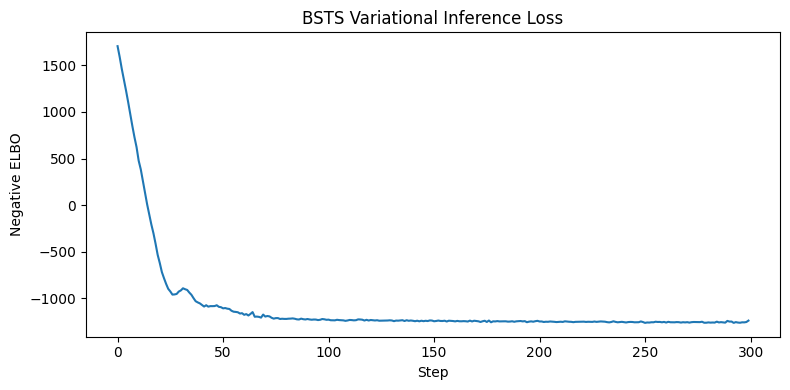

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(elbo_loss_curve)
plt.title("BSTS Variational Inference Loss")
plt.xlabel("Step")
plt.ylabel("Negative ELBO")
plt.tight_layout()
plt.show()

Although the ELBO plot seems to indicate stabilization by 100 steps, using <150 steps let to unstable models and poor convergence.

In [12]:
parameter_samples = surrogate_posterior.sample(100)

forecast_dist = sts.forecast(
    model=bsts_model,
    observed_time_series=observed_train,
    parameter_samples=parameter_samples,
    num_steps_forecast=horizon
)

forecast_mean = forecast_dist.mean().numpy().squeeze()
forecast_std = forecast_dist.stddev().numpy().squeeze()

forecast_samples = forecast_dist.sample(1000).numpy().squeeze()

lower_95 = np.percentile(forecast_samples, 2.5, axis=0)
upper_95 = np.percentile(forecast_samples, 97.5, axis=0)

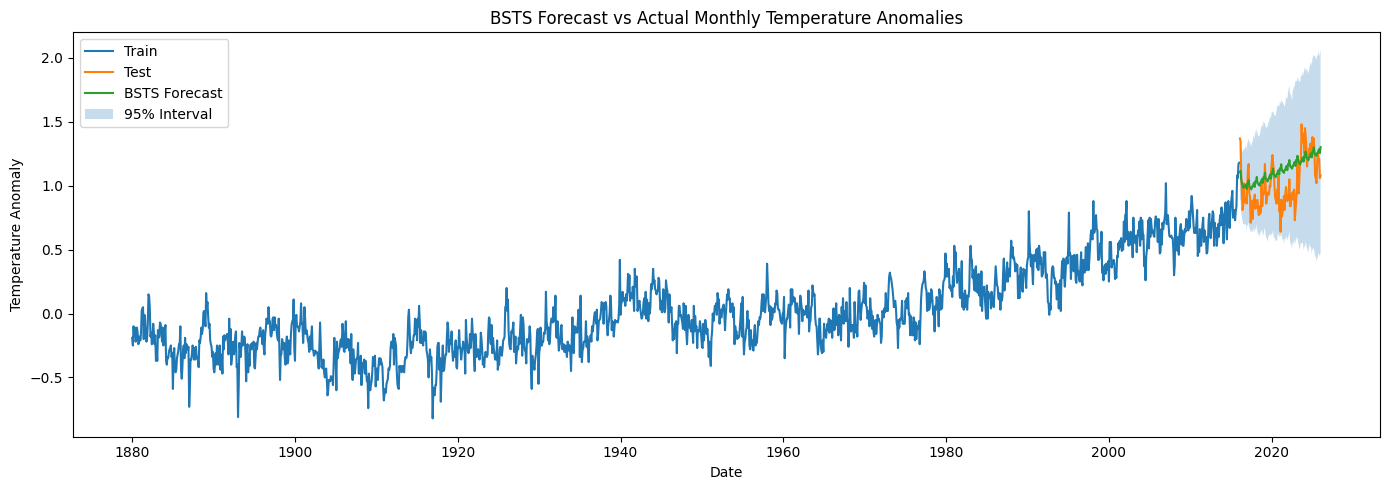

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(train_months.index, train_months.values, label="Train")
plt.plot(test_months.index, test_months.values, label="Test")
plt.plot(test_months.index, forecast_mean, label="BSTS Forecast")
plt.fill_between(
    test_months.index,
    lower_95,
    upper_95,
    alpha=0.25,
    label="95% Interval"
)
plt.title("BSTS Forecast vs Actual Monthly Temperature Anomalies")
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly")
plt.legend()
plt.tight_layout()
plt.show()

***There seems to be some overprediction, and this appears to be largely driven by the trend component; this suggests that the last 10 years are dropping below what we would expect based on trend alone.  See below for the decomposition forecasts.***

In [14]:
component_dists = sts.decompose_by_component(
    model=bsts_model,
    observed_time_series=observed_train,
    parameter_samples=parameter_samples
)

component_means = {
    comp: dist.mean().numpy().squeeze()
    for comp, dist in component_dists.items()
}

forecast_component_dists = sts.decompose_forecast_by_component(
    model=bsts_model,
    forecast_dist=forecast_dist,
    parameter_samples=parameter_samples
)

for comp, dist in forecast_component_dists.items():
    print(comp.name, dist.mean().shape) #The model still works fairly efficiently, but note the warning below

trend/ (120,)
monthly_seasonality/ (120,)
ar1/ (120,)


In [15]:
def plot_component_history_and_forecast(component, title, ylabel="Contribution"):
    hist = component_means[component]
    fut_dist = forecast_component_dists[component]

    fut_mean = fut_dist.mean().numpy().squeeze()
    fut_std = fut_dist.stddev().numpy().squeeze()
    fut_lower = fut_mean - 1.96 * fut_std
    fut_upper = fut_mean + 1.96 * fut_std

    plt.figure(figsize=(14, 5))
    plt.plot(train_months.index, hist, label=f"{component.name} history")
    plt.plot(test_months.index, fut_mean, label=f"{component.name} forecast")
    plt.fill_between(test_months.index, fut_lower, fut_upper, alpha=0.25, label="95% interval")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

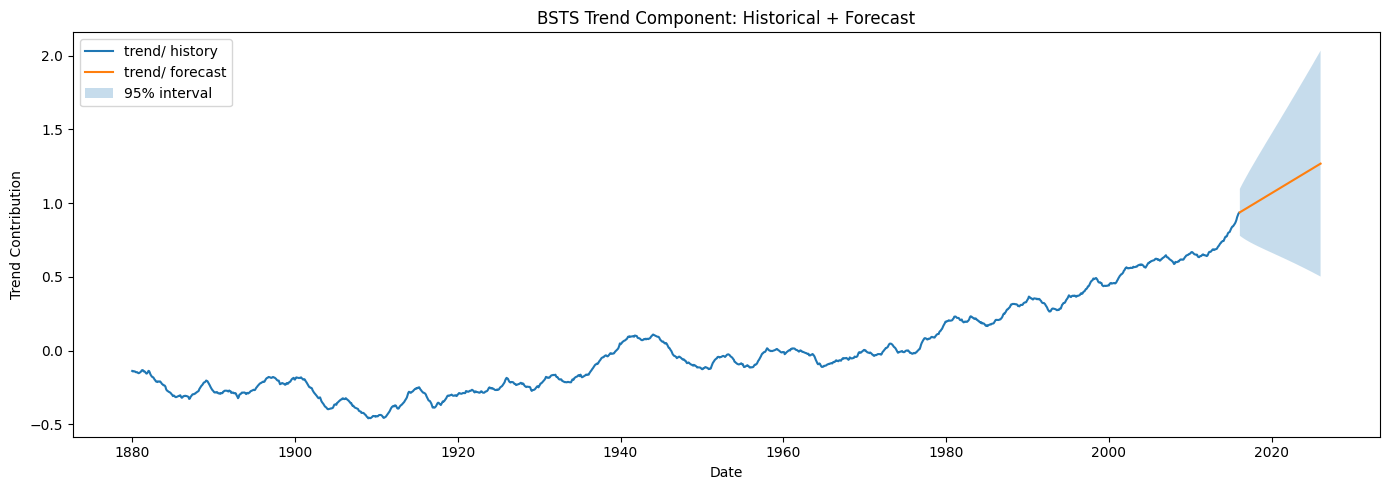

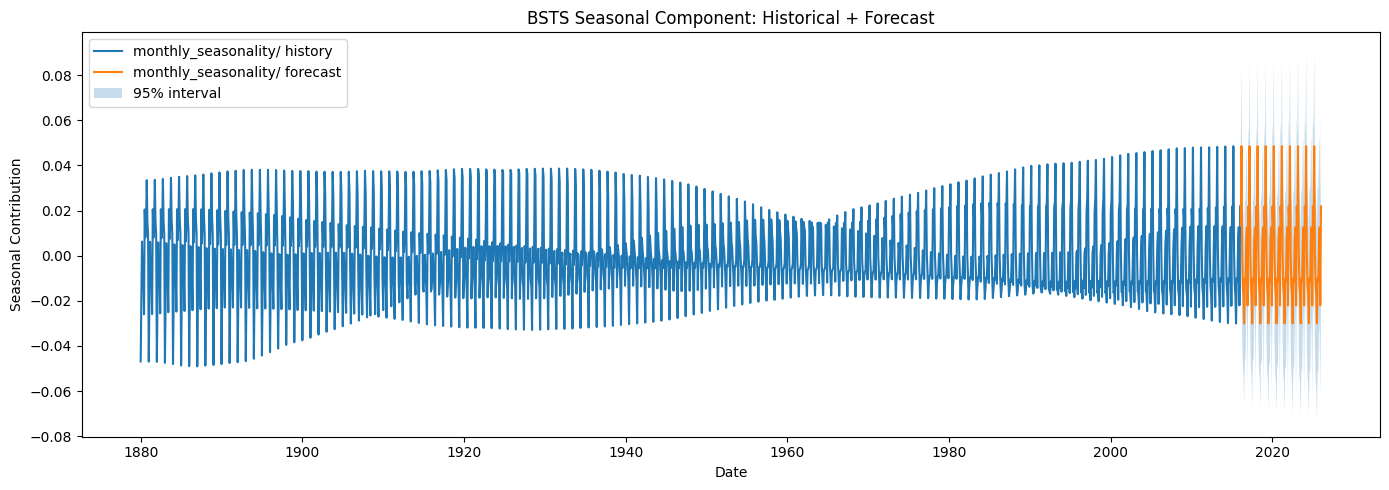

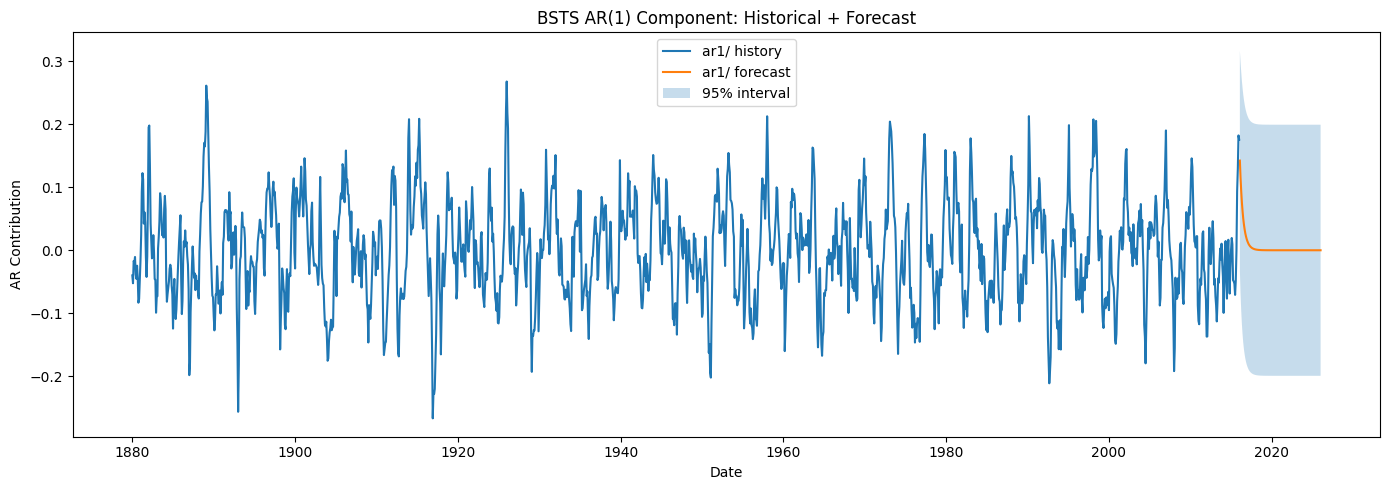

In [16]:
plot_component_history_and_forecast(
    trend,
    "BSTS Trend Component: Historical + Forecast",
    ylabel="Trend Contribution"
)

plot_component_history_and_forecast(
    seasonal,
    "BSTS Seasonal Component: Historical + Forecast",
    ylabel="Seasonal Contribution"
)

plot_component_history_and_forecast(
    ar,
    "BSTS AR(1) Component: Historical + Forecast",
    ylabel="AR Contribution"
)

***As discussed above, the trend overestimates temperatures.  The effect of the AR(1) component quickly drops off, as expected, though with high credible intervals.  Residual seasonality seems to be lower from ~1950 to 1980, but this is an artifact from the way that the anomaly temperature is calculated - from an average monthly temperature from 1951 to 1980.***

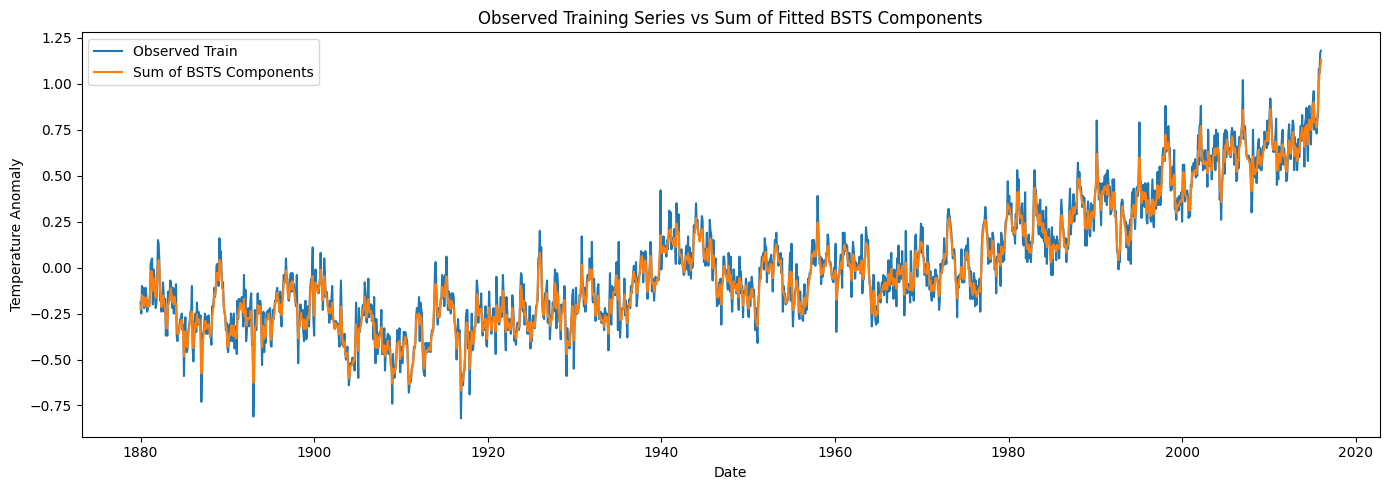

In [17]:
fitted_sum = np.sum(np.column_stack(list(component_means.values())), axis=1)

plt.figure(figsize=(14, 5))
plt.plot(train_months.index, train_months.values, label="Observed Train")
plt.plot(train_months.index, fitted_sum, label="Sum of BSTS Components")
plt.title("Observed Training Series vs Sum of Fitted BSTS Components")
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly")
plt.legend()
plt.tight_layout()
plt.show()

### BSTS diagnostics
These diagnostics focus on two error series:

- **training residuals**: observed training values minus the fitted sum of the latent components
- **forecast errors**: observed test values minus the forecast mean

They help assess bias, shape, and remaining serial dependence.

In [18]:
train_residuals = train_months.values - fitted_sum
forecast_error = test_months.values - forecast_mean

print("Forecast MAE:", np.mean(np.abs(forecast_error)))
print("Forecast RMSE:", np.sqrt(np.mean(forecast_error**2)))
print("Mean forecast error:", np.mean(forecast_error))

Forecast MAE: 0.15445979
Forecast RMSE: 0.18424053
Mean forecast error: -0.10526943


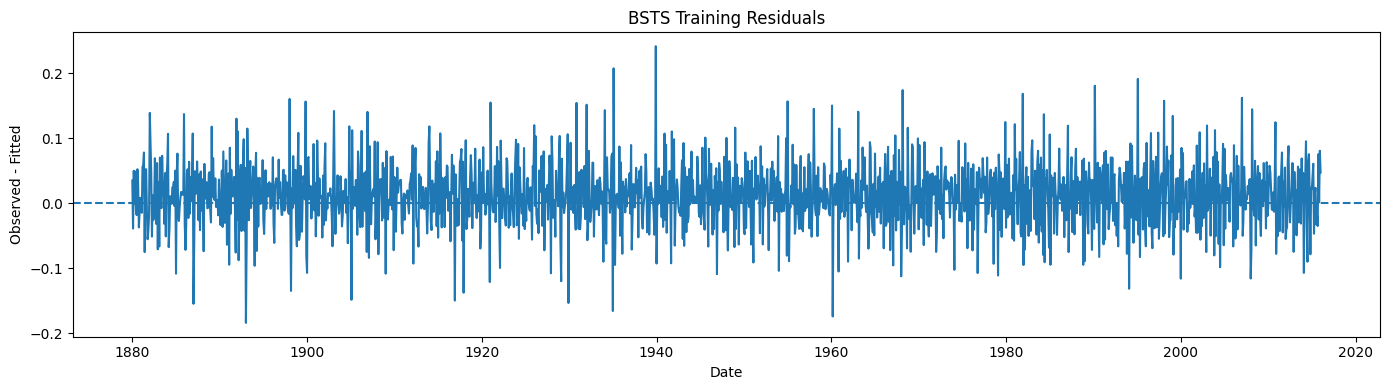

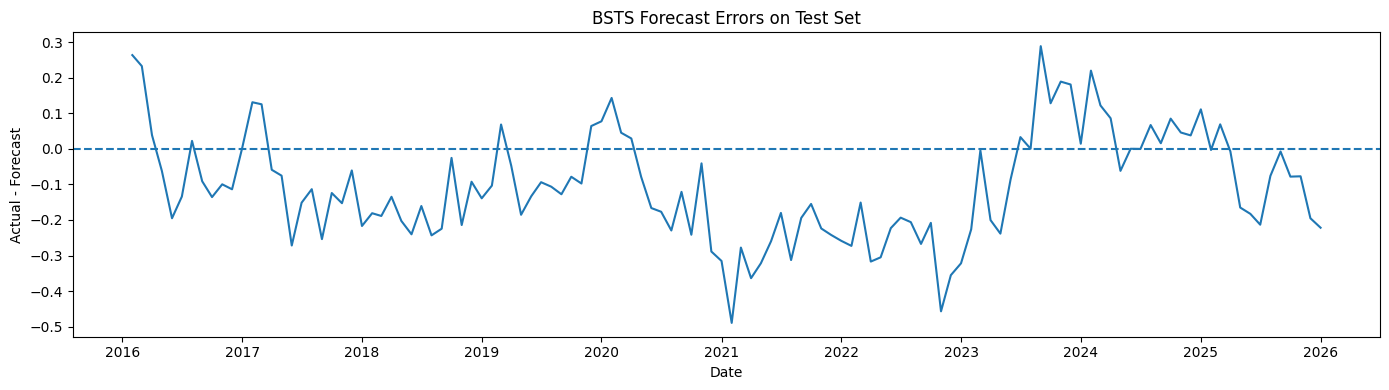

In [19]:
plt.figure(figsize=(14, 4))
plt.plot(train_months.index, train_residuals)
plt.axhline(0, linestyle="--")
plt.title("BSTS Training Residuals")
plt.xlabel("Date")
plt.ylabel("Observed - Fitted")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(test_months.index, forecast_error)
plt.axhline(0, linestyle="--")
plt.title("BSTS Forecast Errors on Test Set")
plt.xlabel("Date")
plt.ylabel("Actual - Forecast")
plt.tight_layout()
plt.show()

Forecast errors exhibit a persistent and increasingly negative bias over the test period, indicating systematic overprediction. The temporal drift in errors suggests that the Local Linear Trend component extrapolates a slope that is steeper than observed in the holdout data, leading to progressively larger deviations.  One way to avoid this may be to use sts.LocalLevel() instead, since it will avoid overextrapolation (this was tried, but resulted in underestimation of the trend).  On the other hand, the model seems to capture long term structure well, but it seems to miss a deviation within the timeseries that is localized to the time directly after the training dataset.  Around ~2020–2023 in particular, the data dips below the model, though the trend then continues to follow the predicted slope.  This demonstrates the failure of this model (or any model) to capture temporary shocks and it seems likey that this shock correlates with the the COVID pandemic, possible due to a substantial drop in the number of cars on the road during that period.

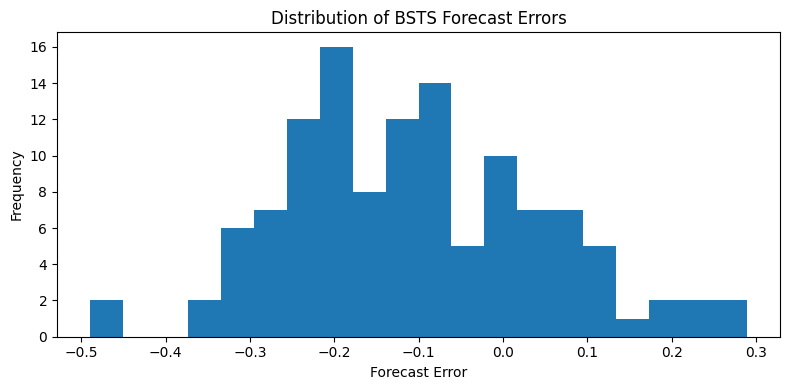

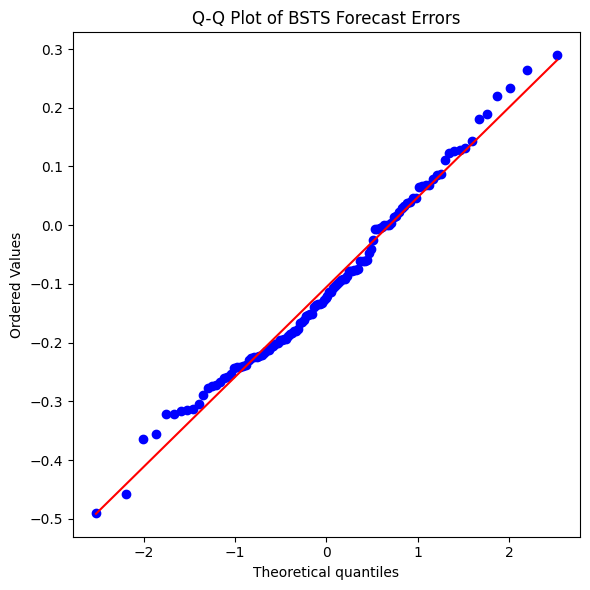

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(forecast_error, bins=20)
plt.title("Distribution of BSTS Forecast Errors")
plt.xlabel("Forecast Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(forecast_error, dist="norm", plot=plt)
plt.title("Q-Q Plot of BSTS Forecast Errors")
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

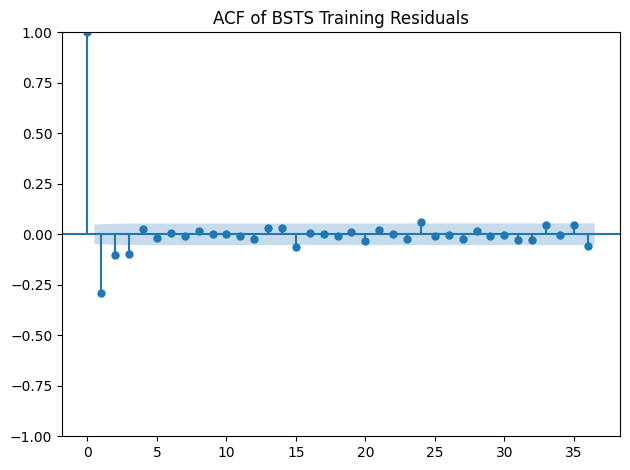

<Figure size 800x400 with 0 Axes>

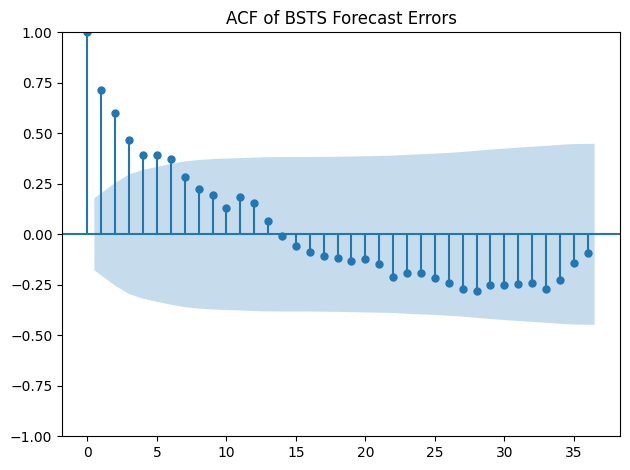

In [21]:
plt.figure(figsize=(8, 4))
plot_acf(train_residuals, lags=36)
plt.title("ACF of BSTS Training Residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plot_acf(forecast_error, lags=min(36, len(forecast_error) - 1))
plt.title("ACF of BSTS Forecast Errors")
plt.tight_layout()
plt.show()

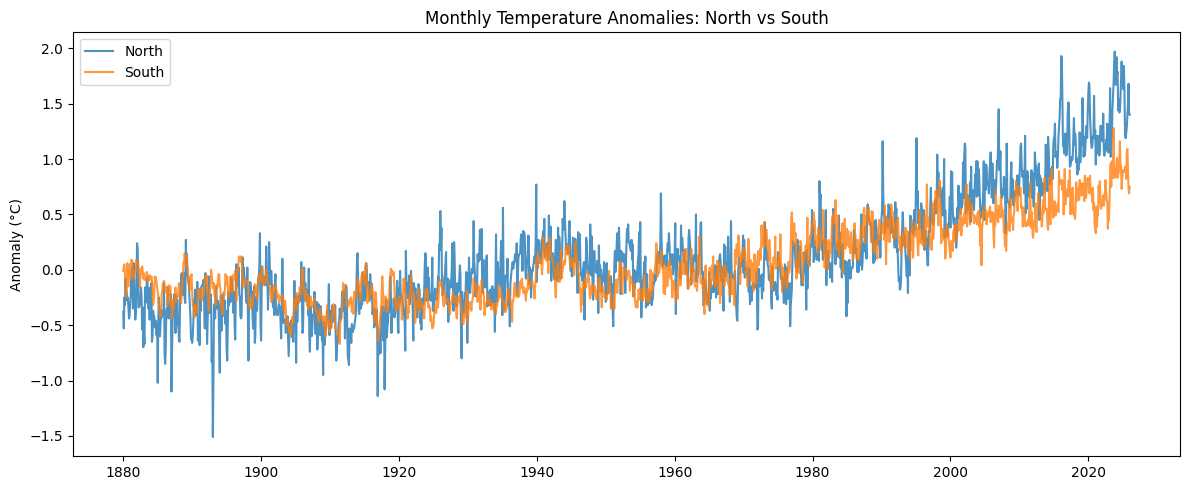

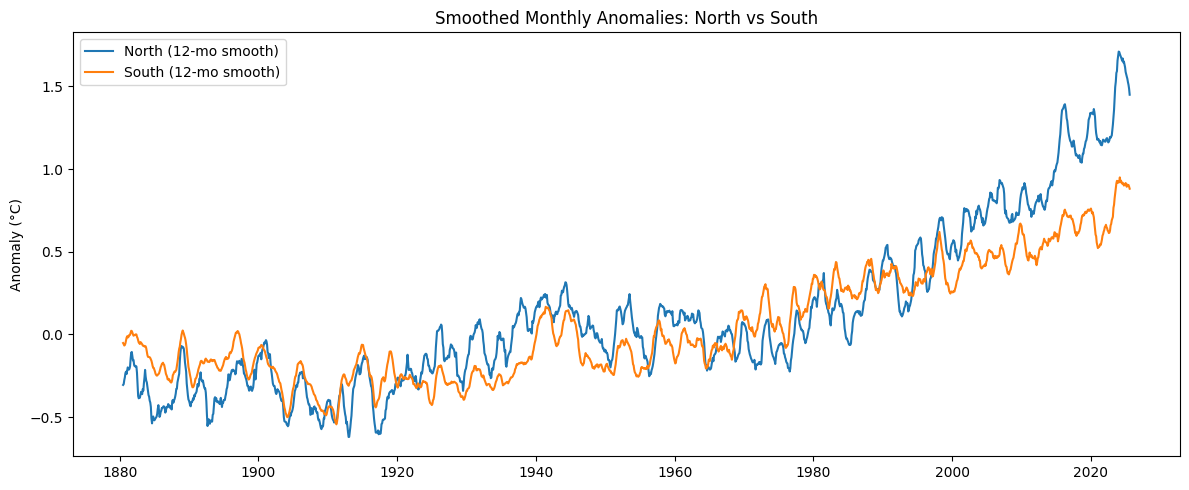

In [22]:
tfd = tfp.distributions
sts = tfp.sts

# ---------- Load monthly hemisphere data ----------
def load_hemi_monthly(path, name):
    raw = pd.read_csv(path, header=None)
    raw.columns = raw.iloc[1]
    df = raw.iloc[2:].copy()

    month_cols = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    df = df[['Year'] + month_cols]

    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    for c in month_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df = df.dropna(subset=['Year'])
    long_df = df.melt(id_vars='Year', var_name='Month', value_name='Anomaly').dropna()

    month_map = {m:i+1 for i,m in enumerate(month_cols)}
    long_df['month_num'] = long_df['Month'].map(month_map)
    long_df['date'] = pd.to_datetime(dict(year=long_df['Year'].astype(int),
                                          month=long_df['month_num'],
                                          day=1))
    long_df = long_df.sort_values('date')
    s = pd.Series(long_df['Anomaly'].values, index=long_df['date'], name=name)
    return s.astype(np.float32)

north = load_hemi_monthly("data/NH.Ts+dSST.csv", "North")
south = load_hemi_monthly("data/SH.Ts+dSST.csv", "South")

# ---------- Quick raw comparison ----------
plt.figure(figsize=(12,5))
plt.plot(north.index, north.values, label="North", alpha=0.8)
plt.plot(south.index, south.values, label="South", alpha=0.8)
plt.title("Monthly Temperature Anomalies: North vs South")
plt.ylabel("Anomaly (°C)")
plt.legend()
plt.tight_layout()
plt.show()

# Optional smoothing plot for presentation clarity
north_roll = north.rolling(12, center=True).mean()
south_roll = south.rolling(12, center=True).mean()

plt.figure(figsize=(12,5))
plt.plot(north_roll.index, north_roll.values, label="North (12-mo smooth)")
plt.plot(south_roll.index, south_roll.values, label="South (12-mo smooth)")
plt.title("Smoothed Monthly Anomalies: North vs South")
plt.ylabel("Anomaly (°C)")
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
#  BSTS helper 
def fit_bsts(series, forecast_steps=120, vi_steps=200):
    y = series.values.astype(np.float32)[..., np.newaxis]

    model = sts.Sum([
        sts.LocalLinearTrend(observed_time_series=y),
        sts.Seasonal(num_seasons=12, observed_time_series=y),
        sts.Autoregressive(order=1, observed_time_series=y)
    ], observed_time_series=y)

    surrogate_posterior = tfp.sts.build_factored_surrogate_posterior(model=model)

    optimizer = tf.optimizers.Adam(learning_rate=0.1)
    @tf.function(autograph=False)
    def train():
        return tfp.vi.fit_surrogate_posterior(
            target_log_prob_fn=model.joint_distribution(observed_time_series=y).log_prob,
            surrogate_posterior=surrogate_posterior,
            optimizer=optimizer,
            num_steps=vi_steps
        )

    train()

    q_samples = surrogate_posterior.sample(50)
    forecast_dist = tfp.sts.forecast(model, observed_time_series=y,
                                     parameter_samples=q_samples,
                                     num_steps_forecast=forecast_steps)

    forecast_mean = forecast_dist.mean().numpy().squeeze()
    forecast_sd = forecast_dist.stddev().numpy().squeeze()

    comp_dists = sts.decompose_by_component(model, y, parameter_samples=q_samples)
    comp_means = {k: v.mean().numpy().squeeze() for k, v in comp_dists.items()}

    future_index = pd.date_range(series.index[-1] + pd.offsets.MonthBegin(1),
                                 periods=forecast_steps, freq="MS")

    return {
        "model": model,
        "forecast_mean": pd.Series(forecast_mean, index=future_index),
        "forecast_sd": pd.Series(forecast_sd, index=future_index),
        "components": {k: pd.Series(v, index=series.index) for k, v in comp_means.items()}
    }


In [24]:
north_fit = fit_bsts(north, forecast_steps=120, vi_steps=200)
south_fit = fit_bsts(south, forecast_steps=120, vi_steps=200)

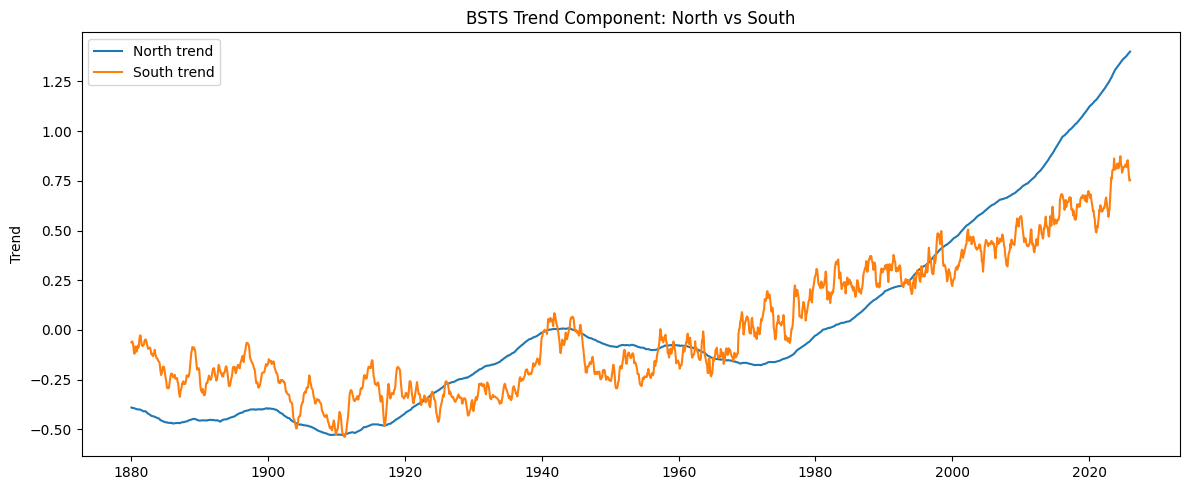

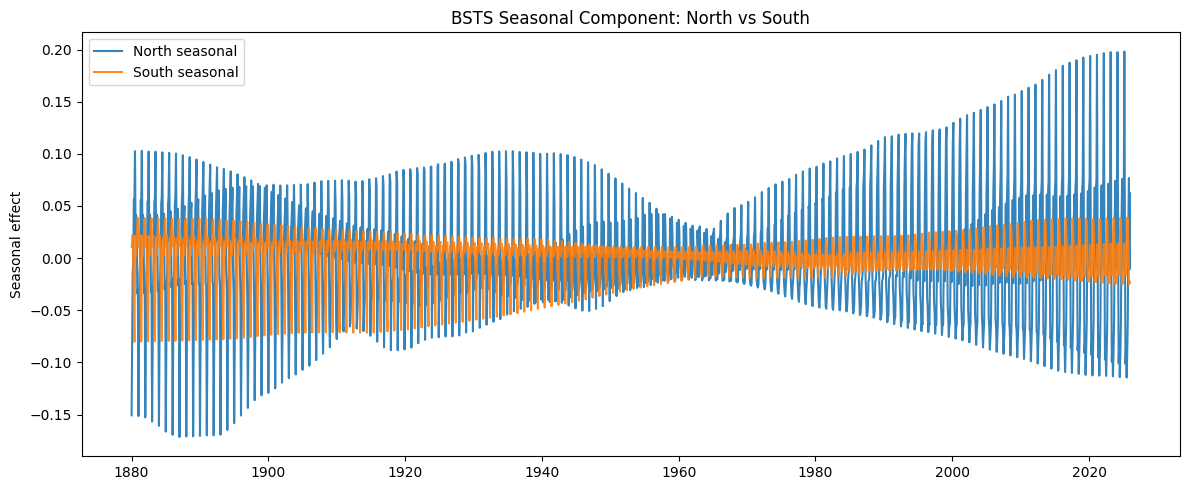

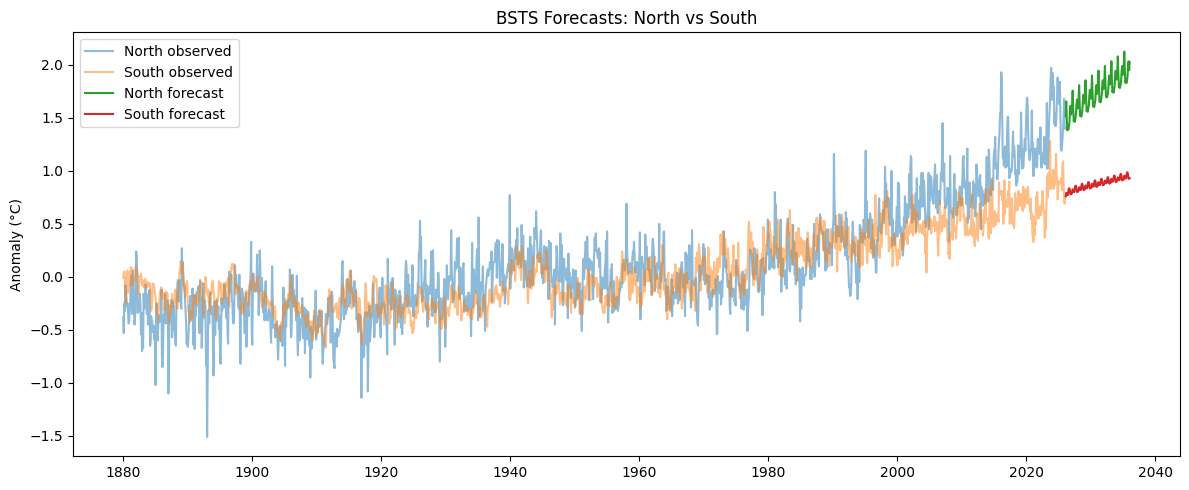

In [25]:
def pick_component(comp_dict, keyword):
    for k in comp_dict:
        if keyword.lower() in str(k).lower():
            return comp_dict[k]
    return None

north_trend = pick_component(north_fit["components"], "LocalLinearTrend")
south_trend = pick_component(south_fit["components"], "LocalLinearTrend")

north_season = pick_component(north_fit["components"], "Seasonal")
south_season = pick_component(south_fit["components"], "Seasonal")

#  Trend comparison
plt.figure(figsize=(12,5))
if north_trend is not None:
    plt.plot(north_trend.index, north_trend.values, label="North trend")
if south_trend is not None:
    plt.plot(south_trend.index, south_trend.values, label="South trend")
plt.title("BSTS Trend Component: North vs South")
plt.ylabel("Trend")
plt.legend()
plt.tight_layout()
plt.show()

#  Seasonal comparison 
plt.figure(figsize=(12,5))
if north_season is not None:
    plt.plot(north_season.index, north_season.values, label="North seasonal", alpha=0.9)
if south_season is not None:
    plt.plot(south_season.index, south_season.values, label="South seasonal", alpha=0.9)
plt.title("BSTS Seasonal Component: North vs South")
plt.ylabel("Seasonal effect")
plt.legend()
plt.tight_layout()
plt.show()

#  Forecast comparison 
plt.figure(figsize=(12,5))
plt.plot(north.index, north.values, label="North observed", alpha=0.5)
plt.plot(south.index, south.values, label="South observed", alpha=0.5)

plt.plot(north_fit["forecast_mean"].index, north_fit["forecast_mean"].values, label="North forecast")
plt.plot(south_fit["forecast_mean"].index, south_fit["forecast_mean"].values, label="South forecast")

plt.title("BSTS Forecasts: North vs South")
plt.ylabel("Anomaly (°C)")
plt.legend()
plt.tight_layout()
plt.show()

The estimated Southern Hemisphere trend appeared less smooth than the Northern Hemisphere trend in several runs.  It is unclear what may be causing this, but it could be a consequence of the smaller amount of data for the southern hemisphere, leading to variation in trend estimation, greater medium-term variability in the southern series or greater sensitivity in in the model for how variation is assigned.  This may be the result of the fact that clean orthogonal assignment of variation between model terms may be difficult for some data sets (possibly there is enough data in the northern dataset to overcome this), in this case there seems to be an identifiability problem between latent components of the model.

The Southern dataset seems to be trending much lower than the northern dataset.  The reason for this is unknown, though it may relate to the amount of water in the summer hemisphere, which may result in some buffering of the effects of climate change.

In [26]:
y_train = train_months.copy()
y_test = test_months.copy()

In [27]:
tscv = TimeSeriesSplit(n_splits=5, test_size=24)
cv_errors = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(y_train), 1):
    fold_train = y_train.iloc[train_idx]
    fold_val = y_train.iloc[val_idx]

    fold_fit = fit_bsts(
        fold_train,
        forecast_steps=len(fold_val),
        vi_steps=200
    )

    fold_pred = fold_fit["forecast_mean"]

    fold_mse = mean_squared_error(fold_val, fold_pred)
    cv_errors.append(float(fold_mse))

    print(f"Fold {fold} MSE: {fold_mse:.4f}")

print("CV errors:", cv_errors)
print("Mean CV MSE:", np.mean(cv_errors))

Fold 1 MSE: 0.0183
Fold 2 MSE: 0.0437
Fold 3 MSE: 0.0172
Fold 4 MSE: 0.0164
Fold 5 MSE: 0.0268
CV errors: [0.01832115650177002, 0.04370066523551941, 0.017249682918190956, 0.016448020935058594, 0.026817604899406433]
Mean CV MSE: 0.02450742609798908


BSTS export lengths: 120 120
BSTS export first 5 actual: [1.37 1.35 1.09 0.96 0.81]
BSTS export first 5 pred: [1.1057703 1.1167744 1.0511458 1.0215452 1.0050888]
BSTS export last 5 actual: [1.25 1.2  1.21 1.06 1.08]
BSTS export last 5 pred: [1.2571881 1.277915  1.2869762 1.2551239 1.3017651]


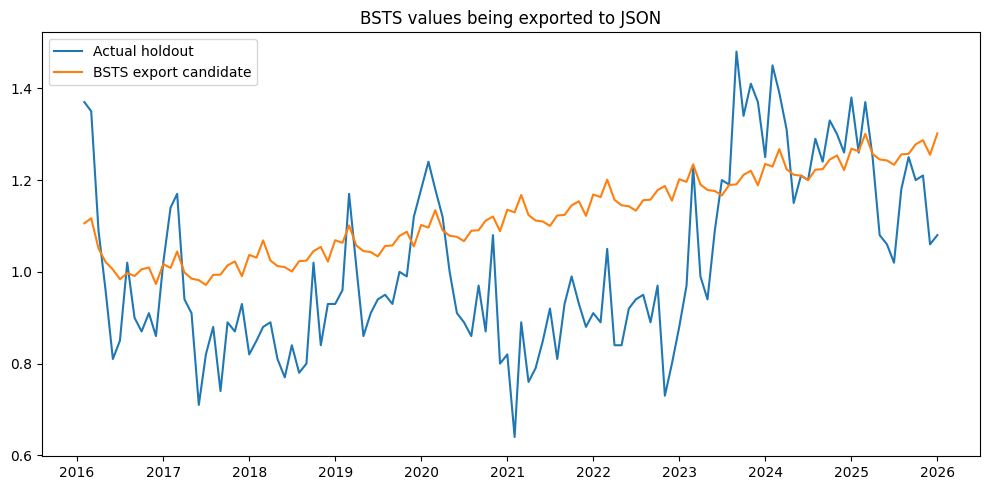

Saved C:\Users\brend\education\Stat 656\Final_Project\Code\bsts_results.json


In [28]:
# Use the already-fitted earlier forecast from cell 13
bsts_export_test = test_months.copy()

bsts_export_pred = pd.Series(
    np.asarray(forecast_mean).reshape(-1),
    index=bsts_export_test.index
)

print("BSTS export lengths:", len(bsts_export_test), len(bsts_export_pred))
print("BSTS export first 5 actual:", np.asarray(bsts_export_test)[:5])
print("BSTS export first 5 pred:", np.asarray(bsts_export_pred)[:5])
print("BSTS export last 5 actual:", np.asarray(bsts_export_test)[-5:])
print("BSTS export last 5 pred:", np.asarray(bsts_export_pred)[-5:])

plt.figure(figsize=(10, 5))
plt.plot(bsts_export_test.index, bsts_export_test.values, label="Actual holdout")
plt.plot(bsts_export_pred.index, bsts_export_pred.values, label="BSTS export candidate")
plt.title("BSTS values being exported to JSON")
plt.legend()
plt.tight_layout()
plt.show()

bsts_export_results = { 
    "model_name": "BSTS",
    "cv_metric_name": "MSE",
    "cv_errors": list(cv_errors),
    "holdout_actual": np.asarray(bsts_export_test).tolist(),
    "holdout_pred": np.asarray(bsts_export_pred).tolist()
} #To be included (with appropriate corrections) in each model to export .json files for model comparison

from pathlib import Path
import json

bsts_out_path = Path("bsts_results.json")
with open(bsts_out_path, "w") as f:
    json.dump(bsts_export_results, f, indent=2)

print(f"Saved {bsts_out_path.resolve()}")